In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv('/content/stroke (1).csv')
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0.5,0.816895,0,1,1,0.50,1,0.801265,0.301260,0.333333,1
1,0.0,0.743652,0,0,1,0.75,0,0.679023,0.212981,0.666667,1
2,0.5,0.975586,0,1,1,0.50,0,0.234512,0.254296,0.666667,1
3,0.0,0.597168,0,0,1,0.50,1,0.536008,0.276060,1.000000,1
4,0.0,0.963379,1,0,1,0.75,0,0.549349,0.156930,0.666667,1


In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (5110, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   float64
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   int64  
 5   work_type          5110 non-null   float64
 6   Residence_type     5110 non-null   int64  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   float64
 10  stroke             5110 non-null   int64  
dtypes: float64(6), int64(5)
memory usage: 439.3 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,5110.0,0.207143,0.246522,0.0,0.000000,0.000000,0.500000,1.0
age,5110.0,0.526692,0.276033,0.0,0.304199,0.548340,0.743652,1.0
hypertension,5110.0,0.097456,0.296607,0.0,0.000000,0.000000,0.000000,1.0
heart_disease,5110.0,0.054012,0.226063,0.0,0.000000,0.000000,0.000000,1.0
ever_married,5110.0,0.656164,0.475034,0.0,0.000000,1.000000,1.000000,1.0
work_type,5110.0,0.541928,0.272573,0.0,0.500000,0.500000,0.750000,1.0
Residence_type,5110.0,0.508023,0.499985,0.0,0.000000,1.000000,1.000000,1.0
avg_glucose_level,5110.0,0.235563,0.209046,0.0,0.102137,0.169721,0.272228,1.0
bmi,5110.0,0.212981,0.088179,0.0,0.154639,0.207331,0.257732,1.0
smoking_status,5110.0,0.458969,0.357178,0.0,0.000000,0.666667,0.666667,1.0


stroke
0    4861
1     249
Name: count, dtype: int64


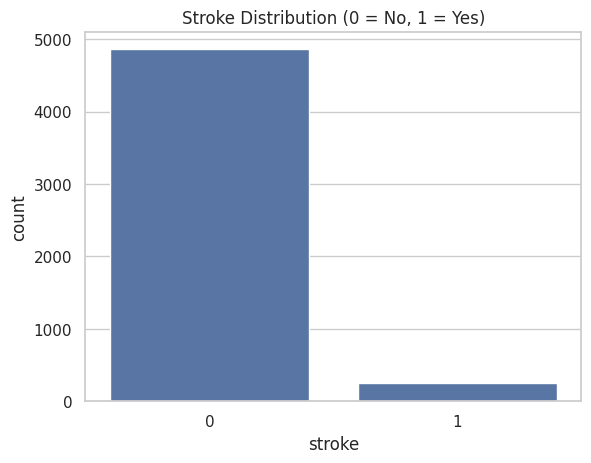

In [ ]:
print(df['stroke'].value_counts())
sns.countplot(x='stroke', data=df)
plt.title('Stroke Distribution (0 = No, 1 = Yes)')
plt.show()

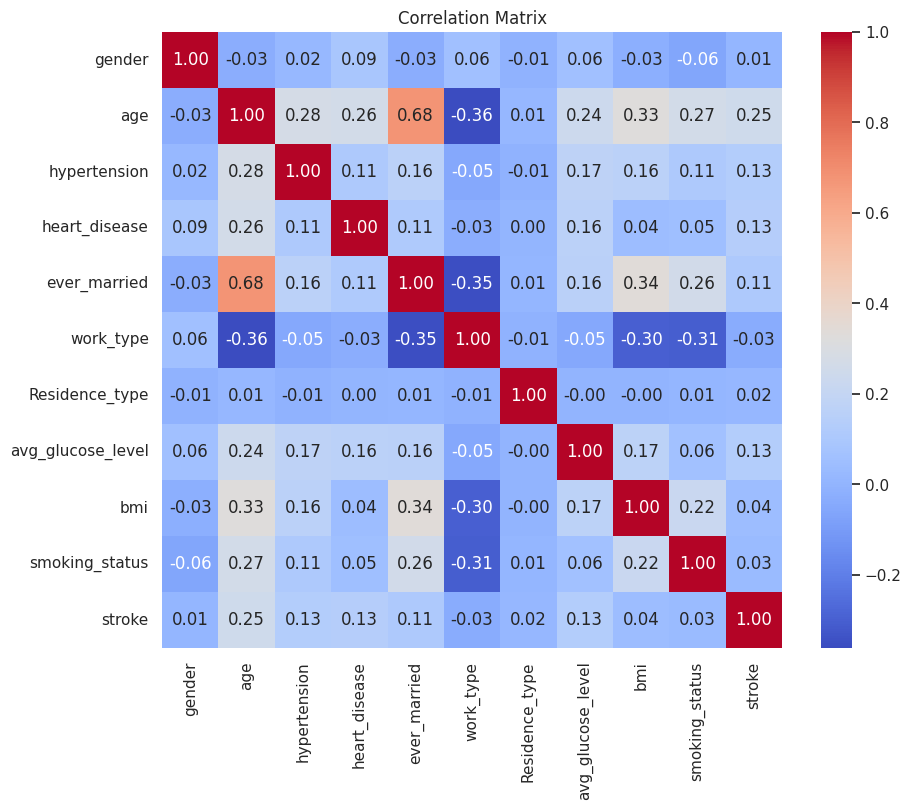

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df.corr()['stroke'].sort_values(ascending=False)

,stroke
stroke,1.000000
age,0.245257
heart_disease,0.134914
avg_glucose_level,0.131945
hypertension,0.127904
ever_married,0.108340
bmi,0.038947
smoking_status,0.028123
Residence_type,0.015458
gender,0.008929


In [ ]:
print("Missing values per column:\n", df.isnull().sum())
print("\nTotal duplicated rows:", df.duplicated().sum())

df = df.drop_duplicates()
df = df.dropna()
print("Shape after cleaning:", df.shape)

Missing values per column:
 gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Total duplicated rows: 0
Shape after cleaning: (5110, 11)


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns needing encoding:", list(categorical_cols))

if len(categorical_cols) > 0:
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])
else:
    print("No encoding needed — data already numeric/encoded.")

Categorical columns needing encoding: []
No encoding needed — data already numeric/encoded.


In [ ]:
X = df.drop('stroke', axis=1)
y = df['stroke']

print(X.shape, y.shape)

(5110, 10) (5110,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4088, 10) Test: (1022, 10)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_proba))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy : 0.7524461839530333
Precision: 0.1413427561837456
Recall   : 0.8
F1 Score : 0.24024024024024024
ROC AUC  : 0.8386008230452675

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.78      0.55      1022
weighted avg       0.95      0.75      0.82      1022



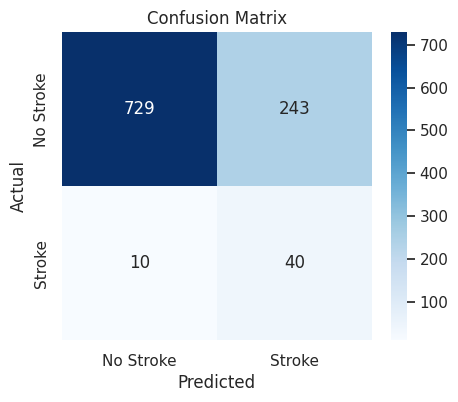

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke','Stroke'],
            yticklabels=['No Stroke','Stroke'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

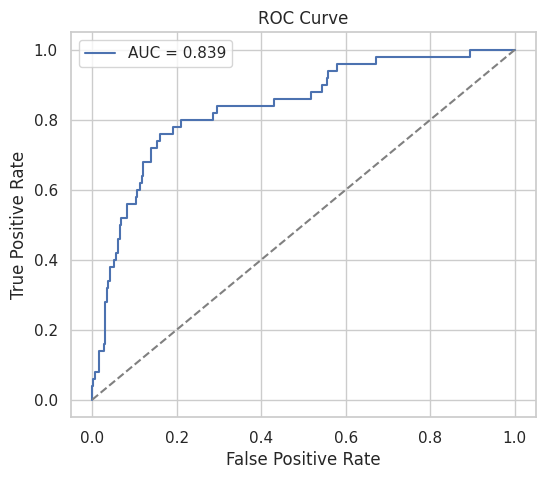

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()